In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [33]:
data=pd.read_csv("student_dropout_dataset_v3.csv")
data.head(6)

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0
5,6,20.5,Male,25000.0,Yes,4.11,89.1,2,47.1,No,Yes,6.0,2.52,2.72,2.69,Year 3,Business,NaN,0


In [4]:
print(data.columns)
print(data.shape)
print(data.info())

Index(['Student_ID', 'Age', 'Gender', 'Family_Income', 'Internet_Access',
       'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days',
       'Travel_Time_Minutes', 'Part_Time_Job', 'Scholarship', 'Stress_Index',
       'GPA', 'Semester_GPA', 'CGPA', 'Semester', 'Department',
       'Parental_Education', 'Dropout'],
      dtype='object')
(10000, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  int64  
 1   Age                    10000 non-null  float64
 2   Gender                 10000 non-null  object 
 3   Family_Income          9500 non-null   float64
 4   Internet_Access        10000 non-null  object 
 5   Study_Hours_per_Day    9500 non-null   float64
 6   Attendance_Rate        10000 non-null  float64
 7   Assignment_Delay_Days  10000 non-null  int64  
 8   Tr

In [5]:
data=data.dropna()
data = data[[
    "Gender",
    "Family_Income",
    "Study_Hours_per_Day",
    "Attendance_Rate",
    "Part_Time_Job",
    "Scholarship",
    "Stress_Index",
    "GPA",
    "Dropout"
]]
for col in data.select_dtypes(include='object').columns:
    le=LabelEncoder()
    data[col]=le.fit_transform(data[col])
data.head(5)

,Gender,Family_Income,Study_Hours_per_Day,Attendance_Rate,Part_Time_Job,Scholarship,Stress_Index,GPA,Dropout
0,1,25000.0,3.36,86.1,1,0,5.5,0.96,0
1,1,25000.0,4.30,68.0,0,0,6.8,1.28,1
2,1,40183.0,4.40,70.9,1,0,5.5,1.68,0
4,0,25319.0,4.19,75.7,0,0,7.0,1.48,0
6,1,25000.0,3.00,78.2,1,1,7.3,0.64,0


In [6]:
x = data.drop("Dropout", axis=1)
y = data["Dropout"]

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [8]:
smote = SMOTE(random_state=42)
x_train_scaled, y_train = smote.fit_resample(x_train_scaled, y_train)

In [9]:
model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)
model.fit(x_train_scaled, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [10]:
y_pred = model.predict(x_test_scaled)

In [11]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy * 100)

Accuracy: 76.5521064301552


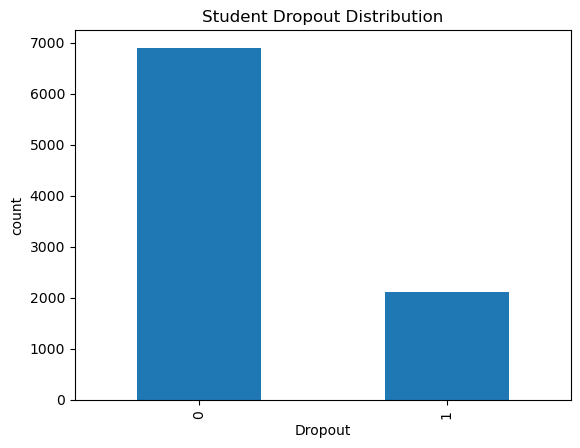

In [31]:
data["Dropout"].value_counts().plot(kind="bar")
plt.title("Student Dropout Distribution")
plt.xlabel("Dropout")
plt.ylabel("count")
plt.show()

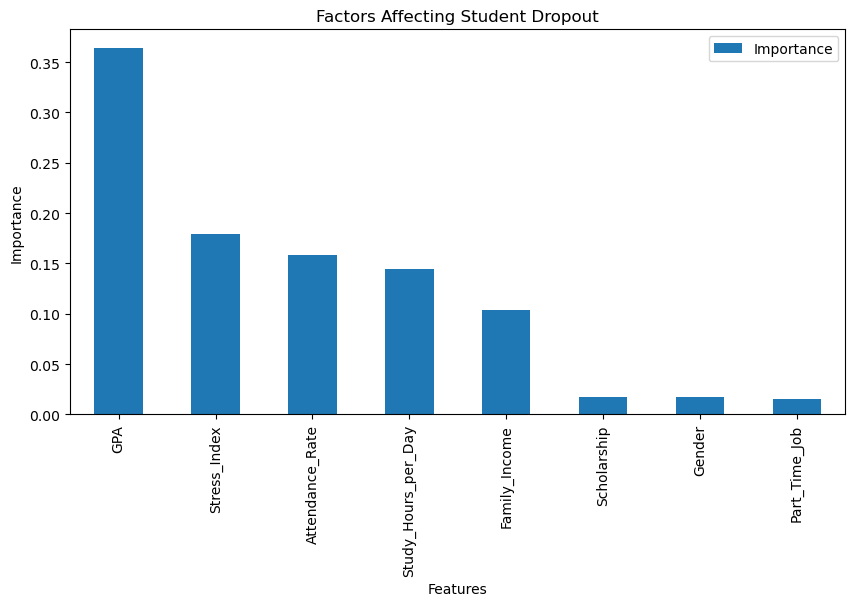

In [32]:
importance=pd.DataFrame({"Feature":x.columns,"Importance":model.feature_importances_})
importance=importance.sort_values(by="Importance",ascending=False)
importance.plot(x="Feature",y="Importance",kind="bar",figsize=(10,5))
plt.title("Factors Affecting Student Dropout")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

In [34]:
joblib.dump(model, "model.pkl",compress=3)
joblib.dump(scaler, "scaler.pkl")
print("Model and Scaler Saved Successfully")

Model and Scaler Saved Successfully
